<a href="https://colab.research.google.com/github/shoujiali/Disaster-Impact-Estimation-Downscaling/blob/main/Downscale.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Tweets raster

In [2]:
import os
import pandas as pd

file_path = '/content/drive/Shareddrives/TAMIDS Disaster Impact Estimation Prediction/Data/Yalong/GRIIDC data/with zip code/Copy of harvey_with_zipcode.csv'

df_harvey_griidc = pd.read_csv(file_path, low_memory=False)
print(f"Successfully loaded {len(df_harvey_griidc)} records from GRIIDC Harvey data.")
display(df_harvey_griidc.head())

Successfully loaded 209004 records from GRIIDC Harvey data.


,possibly_sensitive,lang,geo,conversation_id,author_id,public_metrics,media_urls,media_keys,created_at,entities,reply_settings,context_annotations,text,place_id,place,zip_code,storm_name,place_bbox
0,False,en,{'place_id': '9380bd69f4ecbe4b'},9.084710e+17,3.116070e+09,"{'retweet_count': 0, 'reply_count': 1, 'like_c...",https://pbs.twimg.com/media/DJuJw1HUMAAlniO.jpg,3_908471221829775360,2017-09-14T23:23:17.000Z,"{'hashtags': [{'start': 76, 'end': 83, 'tag': ...",everyone,"[{'domain': {'id': '10', 'name': 'Person', 'de...","Latest ozonesonde balloon flight from Socorro,...",9380bd69f4ecbe4b,"{'type': 'Feature', 'bbox': [-106.3116372, 31....",79927.0,harvey,"(-106.3116372, 31.601718, -106.210306, 31.689387)"
1,False,en,{'place_id': '07d9ca6de0486000'},9.084680e+17,2.828491e+09,"{'retweet_count': 2, 'reply_count': 0, 'like_c...",https://pbs.twimg.com/media/DJuGzHuU8AAC7dk.jpg,3_908467962650095616,2017-09-14T23:11:15.000Z,"{'hashtags': [{'start': 99, 'end': 117, 'tag':...",everyone,"[{'domain': {'id': '10', 'name': 'Person', 'de...",Family and Faculty come together to recognize ...,07d9ca6de0486000,"{'type': 'Feature', 'bbox': [-106.286140441894...",79927.0,harvey,"(-106.28614044189453, 31.637645721435547, -106..."
2,False,en,{'place_id': '07d9ca6de0486000'},9.084680e+17,2.828491e+09,"{'retweet_count': 3, 'reply_count': 0, 'like_c...",https://pbs.twimg.com/media/DJuGzKhUIAIEcUh.jpg,3_908467963400822786,2017-09-14T23:09:56.000Z,"{'hashtags': [{'start': 86, 'end': 104, 'tag':...",everyone,"[{'domain': {'id': '30', 'name': 'Entities [En...",An awesome return of recognizing GOODER schola...,07d9ca6de0486000,"{'type': 'Feature', 'bbox': [-106.286140441894...",79927.0,harvey,"(-106.28614044189453, 31.637645721435547, -106..."
3,False,en,{'place_id': '07d9ca6de0486000'},9.084670e+17,2.828491e+09,"{'retweet_count': 1, 'reply_count': 0, 'like_c...",https://pbs.twimg.com/media/DJuGeRaU8AAqU2X.jpg,3_908467604473311232,2017-09-14T23:08:06.000Z,"{'hashtags': [{'start': 62, 'end': 80, 'tag': ...",everyone,"[{'domain': {'id': '10', 'name': 'Person', 'de...",Meet Mr. Alaniz one of the GOODER additions to...,07d9ca6de0486000,"{'type': 'Feature', 'bbox': [-106.286140441894...",79927.0,harvey,"(-106.28614044189453, 31.637645721435547, -106..."
4,False,en,{'place_id': '07d9ee7b96885000'},9.084150e+17,1.232237e+08,"{'retweet_count': 2, 'reply_count': 0, 'like_c...",https://pbs.twimg.com/media/DJtyqmBVYAAlUuY.jpg,3_908445825931501568,2017-09-14T19:41:12.000Z,"{'urls': [{'start': 96, 'end': 119, 'url': 'ht...",everyone,"[{'domain': {'id': '10', 'name': 'Person', 'de...",Have you already snagged this seasons ultimate...,07d9ee7b96885000,"{'type': 'Feature', 'bbox': [-106.320100614742...",79907.0,harvey,"(-106.32010061474236, 31.67553212898165, -106...."


In [3]:
import ast
import matplotlib.patches as mpatches
import pandas as pd

def _parse_bbox(s):
    """Return (lon_min, lat_min, lon_max, lat_max) or None."""
    try:
        # Check if it's a dict-like string from the 'place' column
        place_dict = ast.literal_eval(s)
        if isinstance(place_dict, dict) and 'bbox' in place_dict:
             bbox = place_dict['bbox']
             if len(bbox) == 4 and all(isinstance(coord, (int, float)) for coord in bbox):
                 return tuple(bbox)
             return None
    except (ValueError, SyntaxError, TypeError):
        pass

    # Fallback to the original string splitting logic provided by the user
    try:
        parts = [float(x.strip('()[] \'\"')) for x in str(s).split(',')]
        return tuple(parts) if len(parts) == 4 else None
    except Exception:
        return None

# Apply the parsing function to the 'place' column
_parsed = df_harvey_griidc['place'].apply(_parse_bbox)
_valid  = _parsed.notna()

# Filter out rows where bbox parsing failed
df_filtered_bbox = df_harvey_griidc[_valid].copy()

# Create columns for the coordinates
_coords = pd.DataFrame(_parsed[_valid].tolist(), columns=['lon_min','lat_min','lon_max','lat_max'], index=df_filtered_bbox.index)
df_filtered_bbox = pd.concat([df_filtered_bbox, _coords], axis=1)

df_filtered_bbox['parsed_bbox'] = _parsed[_valid]

print(f"Original GRIIDC records: {len(df_harvey_griidc)}")
print(f"Records with valid bounding box: {len(df_filtered_bbox)}")
display(df_filtered_bbox.head())

Original GRIIDC records: 209004
Records with valid bounding box: 209004


,possibly_sensitive,lang,geo,conversation_id,author_id,public_metrics,media_urls,media_keys,created_at,entities,...,place_id,place,zip_code,storm_name,place_bbox,lon_min,lat_min,lon_max,lat_max,parsed_bbox
0,False,en,{'place_id': '9380bd69f4ecbe4b'},9.084710e+17,3.116070e+09,"{'retweet_count': 0, 'reply_count': 1, 'like_c...",https://pbs.twimg.com/media/DJuJw1HUMAAlniO.jpg,3_908471221829775360,2017-09-14T23:23:17.000Z,"{'hashtags': [{'start': 76, 'end': 83, 'tag': ...",...,9380bd69f4ecbe4b,"{'type': 'Feature', 'bbox': [-106.3116372, 31....",79927.0,harvey,"(-106.3116372, 31.601718, -106.210306, 31.689387)",-106.311637,31.601718,-106.210306,31.689387,"(-106.3116372, 31.601718, -106.210306, 31.689387)"
1,False,en,{'place_id': '07d9ca6de0486000'},9.084680e+17,2.828491e+09,"{'retweet_count': 2, 'reply_count': 0, 'like_c...",https://pbs.twimg.com/media/DJuGzHuU8AAC7dk.jpg,3_908467962650095616,2017-09-14T23:11:15.000Z,"{'hashtags': [{'start': 99, 'end': 117, 'tag':...",...,07d9ca6de0486000,"{'type': 'Feature', 'bbox': [-106.286140441894...",79927.0,harvey,"(-106.28614044189453, 31.637645721435547, -106...",-106.286140,31.637646,-106.286140,31.637646,"(-106.28614044189453, 31.637645721435547, -106..."
2,False,en,{'place_id': '07d9ca6de0486000'},9.084680e+17,2.828491e+09,"{'retweet_count': 3, 'reply_count': 0, 'like_c...",https://pbs.twimg.com/media/DJuGzKhUIAIEcUh.jpg,3_908467963400822786,2017-09-14T23:09:56.000Z,"{'hashtags': [{'start': 86, 'end': 104, 'tag':...",...,07d9ca6de0486000,"{'type': 'Feature', 'bbox': [-106.286140441894...",79927.0,harvey,"(-106.28614044189453, 31.637645721435547, -106...",-106.286140,31.637646,-106.286140,31.637646,"(-106.28614044189453, 31.637645721435547, -106..."
3,False,en,{'place_id': '07d9ca6de0486000'},9.084670e+17,2.828491e+09,"{'retweet_count': 1, 'reply_count': 0, 'like_c...",https://pbs.twimg.com/media/DJuGeRaU8AAqU2X.jpg,3_908467604473311232,2017-09-14T23:08:06.000Z,"{'hashtags': [{'start': 62, 'end': 80, 'tag': ...",...,07d9ca6de0486000,"{'type': 'Feature', 'bbox': [-106.286140441894...",79927.0,harvey,"(-106.28614044189453, 31.637645721435547, -106...",-106.286140,31.637646,-106.286140,31.637646,"(-106.28614044189453, 31.637645721435547, -106..."
4,False,en,{'place_id': '07d9ee7b96885000'},9.084150e+17,1.232237e+08,"{'retweet_count': 2, 'reply_count': 0, 'like_c...",https://pbs.twimg.com/media/DJtyqmBVYAAlUuY.jpg,3_908445825931501568,2017-09-14T19:41:12.000Z,"{'urls': [{'start': 96, 'end': 119, 'url': 'ht...",...,07d9ee7b96885000,"{'type': 'Feature', 'bbox': [-106.320100614742...",79907.0,harvey,"(-106.32010061474236, 31.67553212898165, -106....",-106.320101,31.675532,-106.320101,31.675532,"(-106.32010061474236, 31.67553212898165, -106...."


In [7]:
import numpy as np
import pandas as pd
import rasterio
from rasterio.transform import from_origin

# Texas extent
TEXAS_LON_MIN, TEXAS_LON_MAX = -107.0, -93.0
TEXAS_LAT_MIN, TEXAS_LAT_MAX = 25.0, 37.0

GRID_SIZE = 0.025

# Raster dimensions
ncols = int(np.ceil((TEXAS_LON_MAX - TEXAS_LON_MIN) / GRID_SIZE))
nrows = int(np.ceil((TEXAS_LAT_MAX - TEXAS_LAT_MIN) / GRID_SIZE))

print("Rows:", nrows)
print("Columns:", ncols)

Rows: 480
Columns: 560


In [8]:
bbox_df = df_filtered_bbox.copy()

coord_cols = ["lon_min", "lat_min", "lon_max", "lat_max"]

for col in coord_cols:
    bbox_df[col] = pd.to_numeric(
        bbox_df[col],
        errors="coerce"
    )

bbox_df = bbox_df.dropna(subset=coord_cols).copy()

# 修正坐标顺序异常
bbox_df = bbox_df[
    (bbox_df["lon_min"] <= bbox_df["lon_max"]) &
    (bbox_df["lat_min"] <= bbox_df["lat_max"])
].copy()

# 只保留与 Texas extent 相交的 bbox
bbox_df = bbox_df[
    ~(
        (bbox_df["lon_max"] < TEXAS_LON_MIN) |
        (bbox_df["lon_min"] > TEXAS_LON_MAX) |
        (bbox_df["lat_max"] < TEXAS_LAT_MIN) |
        (bbox_df["lat_min"] > TEXAS_LAT_MAX)
    )
].copy()

print("Valid tweet bounding boxes:", len(bbox_df))

Valid tweet bounding boxes: 209004


In [9]:
bbox_df["lon_min_clip"] = bbox_df["lon_min"].clip(
    lower=TEXAS_LON_MIN,
    upper=TEXAS_LON_MAX
)

bbox_df["lon_max_clip"] = bbox_df["lon_max"].clip(
    lower=TEXAS_LON_MIN,
    upper=TEXAS_LON_MAX
)

bbox_df["lat_min_clip"] = bbox_df["lat_min"].clip(
    lower=TEXAS_LAT_MIN,
    upper=TEXAS_LAT_MAX
)

bbox_df["lat_max_clip"] = bbox_df["lat_max"].clip(
    lower=TEXAS_LAT_MIN,
    upper=TEXAS_LAT_MAX
)

In [10]:
bbox_df["col_min"] = np.floor(
    (bbox_df["lon_min_clip"] - TEXAS_LON_MIN) / GRID_SIZE
).astype(int)

bbox_df["col_max"] = np.floor(
    (bbox_df["lon_max_clip"] - TEXAS_LON_MIN) / GRID_SIZE
).astype(int)

bbox_df["row_min"] = np.floor(
    (TEXAS_LAT_MAX - bbox_df["lat_max_clip"]) / GRID_SIZE
).astype(int)

bbox_df["row_max"] = np.floor(
    (TEXAS_LAT_MAX - bbox_df["lat_min_clip"]) / GRID_SIZE
).astype(int)

In [11]:
bbox_df["col_min"] = bbox_df["col_min"].clip(0, ncols - 1)
bbox_df["col_max"] = bbox_df["col_max"].clip(0, ncols - 1)

bbox_df["row_min"] = bbox_df["row_min"].clip(0, nrows - 1)
bbox_df["row_max"] = bbox_df["row_max"].clip(0, nrows - 1)

In [12]:
tweet_count_raster = np.zeros(
    (nrows, ncols),
    dtype=np.int32
)

for i, row in enumerate(bbox_df.itertuples(index=False)):

    tweet_count_raster[
        row.row_min : row.row_max + 1,
        row.col_min : row.col_max + 1
    ] += 1

    if (i + 1) % 10000 == 0:
        print(f"Processed {i + 1:,} / {len(bbox_df):,}")

Processed 10,000 / 209,004
Processed 20,000 / 209,004
Processed 30,000 / 209,004
Processed 40,000 / 209,004
Processed 50,000 / 209,004
Processed 60,000 / 209,004
Processed 70,000 / 209,004
Processed 80,000 / 209,004
Processed 90,000 / 209,004
Processed 100,000 / 209,004
Processed 110,000 / 209,004
Processed 120,000 / 209,004
Processed 130,000 / 209,004
Processed 140,000 / 209,004
Processed 150,000 / 209,004
Processed 160,000 / 209,004
Processed 170,000 / 209,004
Processed 180,000 / 209,004
Processed 190,000 / 209,004
Processed 200,000 / 209,004


In [13]:
transform = from_origin(
    TEXAS_LON_MIN,
    TEXAS_LAT_MAX,
    GRID_SIZE,
    GRID_SIZE
)

output_tif = "texas_tweet_count_0025.tif"

with rasterio.open(
    output_tif,
    "w",
    driver="GTiff",
    height=nrows,
    width=ncols,
    count=1,
    dtype=tweet_count_raster.dtype,
    crs="EPSG:4326",
    transform=transform,
    nodata=0,
    compress="lzw"
) as dst:
    dst.write(tweet_count_raster, 1)

print("Saved:", output_tif)

Saved: texas_tweet_count_0025.tif


# fully supervised downscaling

## DEM


In [14]:
## unzip *DEM*

import zipfile
import os

zip_path = "/content/drive/Shareddrives/TAMIDS Disaster Impact Estimation Prediction/Data/GIS_Data/USGSElevation.zip"
extract_folder = "dem_extract"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_folder)

print(os.listdir(extract_folder))

['USGSEle20s']


In [15]:
import geopandas as gpd
import rasterio
from pathlib import Path
from shapely.geometry import box

units = gpd.read_file("/content/drive/MyDrive/Data/tl_2025_48_tract/tl_2025_48_tract.shp")

units = units.to_crs("EPSG:4269")

texas_boundary = units.dissolve().geometry.iloc[0]

dem_folder = Path("/content/dem_extract/USGSEle20s")

selected_files = []

for tif in dem_folder.rglob("*.tif"):
    with rasterio.open(tif) as src:
        b = src.bounds
        tile_box = box(b.left, b.bottom, b.right, b.top)

    if tile_box.intersects(texas_boundary):
        selected_files.append(str(tif))

print("Selected DEM tiles:", len(selected_files))
selected_files[:5]

Selected DEM tiles: 94


['/content/dem_extract/USGSEle20s/USGS_1_n31w097_20240229.tif',
 '/content/dem_extract/USGSEle20s/USGS_1_n32w099_20250509.tif',
 '/content/dem_extract/USGSEle20s/USGS_1_n32w104_20220721.tif',
 '/content/dem_extract/USGSEle20s/USGS_1_n31w102_20201228.tif',
 '/content/dem_extract/USGSEle20s/USGS_1_n35w102_20190916.tif']

<Axes: >

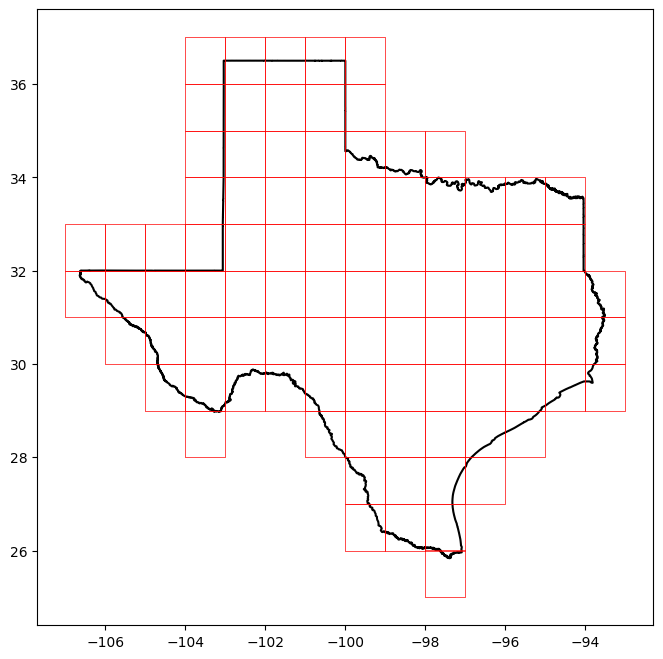

In [16]:
import geopandas as gpd
from shapely.geometry import box
import rasterio

tiles = []

for tif in selected_files:

    with rasterio.open(tif) as src:
        b = src.bounds

    tiles.append(
        box(
            b.left,
            b.bottom,
            b.right,
            b.top
        )
    )

tiles_gdf = gpd.GeoDataFrame(
    geometry=tiles,
    crs="EPSG:4269"
)

ax = units.dissolve().boundary.plot(
    figsize=(8,8),
    color="black"
)

tiles_gdf.boundary.plot(
    ax=ax,
    color="red",
    linewidth=0.5
)

## dataset pro-processing


In [17]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)


class UNet(nn.Module):
    def __init__(self, in_channels):
        super().__init__()

        self.enc1 = DoubleConv(in_channels, 64)
        self.enc2 = DoubleConv(64, 128)
        self.enc3 = DoubleConv(128, 256)

        self.pool = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(256, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = DoubleConv(128, 64)

        self.out = nn.Conv2d(64, 1, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))

        b = self.bottleneck(self.pool(e3))

        d3 = self.up3(b)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        # water depth should be non-negative
        return F.relu(self.out(d1))

In [18]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import rasterio
from rasterio.enums import Resampling
from rasterio.warp import reproject
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader


OUTPUT_TIF = "unet_downscaled_0p1_to_0p025_waterdepth.tif"
# PATCH_SIZE = 160
PATCH_SIZE = 64
STRIDE = 32

BATCH_SIZE = 4
EPOCHS = 50
LEARNING_RATE = 1e-4
SMOOTHNESS_WEIGHT = 0.001

In [19]:
def resolve_raster_path(path_or_candidates):
    candidates = path_or_candidates
    if isinstance(candidates, (str, Path)):
        candidates = [candidates]

    checked = []
    for candidate in candidates:
        candidate = Path(candidate)
        checked.append(str(candidate))
        if candidate.exists():
            return candidate

    raise FileNotFoundError(
        "Could not find raster. Checked: " + ", ".join(checked)
    )


def read_raster(path_or_candidates):
    path = resolve_raster_path(path_or_candidates)
    with rasterio.open(path) as src:
        arr = src.read(1).astype("float32")
        profile = src.profile.copy()
        transform = src.transform
        crs = src.crs
        nodata = src.nodata

    if nodata is not None:
        arr[arr == nodata] = np.nan
    arr[arr <= -9999] = np.nan

    return arr, profile, transform, crs, nodata, path


def same_grid(src_shape, src_transform, src_crs, ref_shape, ref_transform, ref_crs):
    return (
        src_shape == ref_shape
        and src_crs == ref_crs
        and src_transform.almost_equals(ref_transform)
    )


def resample_to_match(
    src_array,
    src_transform,
    src_crs,
    ref_profile,
    ref_transform,
    ref_crs,
    resampling=Resampling.bilinear,
):
    ref_shape = (ref_profile["height"], ref_profile["width"])

    if same_grid(src_array.shape, src_transform, src_crs, ref_shape, ref_transform, ref_crs):
        return src_array.astype("float32")

    dst = np.full(ref_shape, np.nan, dtype="float32")
    reproject(
        source=src_array,
        destination=dst,
        src_transform=src_transform,
        src_crs=src_crs,
        src_nodata=np.nan,
        dst_transform=ref_transform,
        dst_crs=ref_crs,
        dst_nodata=np.nan,
        resampling=resampling,
    )
    dst[dst <= -9999] = np.nan
    return dst.astype("float32")


In [20]:
water_025, water_025_profile, water_025_transform, water_025_crs, water_025_nodata, water_025_path = read_raster(
    "/content/drive/Shareddrives/TAMIDS Disaster Impact Estimation Prediction/Data/Yuning/weather_grid_01deg/HGAC_ERA5wind_PRISMprecip_overlay_zoom/HGAC_0p025_grid_tifs/grid_waterDepth_0025.tif"
)
water_01, water_01_profile, water_01_transform, water_01_crs, water_01_nodata, water_01_path = read_raster(
    "/content/drive/Shareddrives/TAMIDS Disaster Impact Estimation Prediction/Data/Yuning/weather_grid_01deg/HGAC_ERA5wind_PRISMprecip_overlay_zoom/HGAC_0p025_grid_tifs/grid_waterDepth_01.tif"
)
precip_raw, precip_profile, precip_transform, precip_crs, precip_nodata, precip_path = read_raster(
    "/content/drive/Shareddrives/TAMIDS Disaster Impact Estimation Prediction/Data/Yuning/Grid_Texas/ERA5wind_PRISMprecip_Texas/Texas_0p025_grid_tifs/Texas_PRISM_cumulative_precip_mean_mm_0p025deg.tif"
)
wind_raw, wind_profile, wind_transform, wind_crs, wind_nodata, wind_path = read_raster(
    "/content/drive/Shareddrives/TAMIDS Disaster Impact Estimation Prediction/Data/Yuning/Grid_Texas/ERA5wind_PRISMprecip_Texas/Texas_0p025_grid_tifs/Texas_ERA5_max_wind_kts_0p025deg.tif"
)
# dem_raw, dem_profile, dem_transform, dem_crs, dem_nodata, dem_path = read_raster(
#     "/content/dem_extract/USGSEle20s/USGS_1_n29w096_20240229.tif"
# )

In [24]:
import numpy as np
import rasterio
from rasterio.warp import reproject
from rasterio.enums import Resampling

def build_dem_resampled_from_tiles(
    dem_paths,
    target_profile,
    target_transform,
    target_crs,
    resampling_method=Resampling.bilinear
):
    H = target_profile["height"]
    W = target_profile["width"]

    dem_sum = np.zeros((H, W), dtype="float32")
    dem_count = np.zeros((H, W), dtype="float32")

    for i, dem_path in enumerate(dem_paths, 1):
        print(f"[{i}/{len(dem_paths)}] {dem_path}")

        with rasterio.open(dem_path) as src:
            dem = src.read(1).astype("float32")

            src_nodata = src.nodata
            if src_nodata is not None:
                dem[dem == src_nodata] = np.nan

            temp = np.full((H, W), np.nan, dtype="float32")

            reproject(
                source=dem,
                destination=temp,
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=target_transform,
                dst_crs=target_crs,
                src_nodata=np.nan,
                dst_nodata=np.nan,
                resampling=resampling_method
            )

            valid = np.isfinite(temp)

            dem_sum[valid] += temp[valid]
            dem_count[valid] += 1

    dem_resampled = np.full((H, W), np.nan, dtype="float32")

    valid = dem_count > 0
    dem_resampled[valid] = dem_sum[valid] / dem_count[valid]

    return dem_resampled

In [26]:
dem_resampled = build_dem_resampled_from_tiles(
    selected_files,
    water_025_profile,
    water_025_transform,
    water_025_crs
)

print(dem_resampled.shape)
print(np.nanmin(dem_resampled), np.nanmax(dem_resampled))

[1/94] /content/dem_extract/USGSEle20s/USGS_1_n31w097_20240229.tif
[2/94] /content/dem_extract/USGSEle20s/USGS_1_n32w099_20250509.tif
[3/94] /content/dem_extract/USGSEle20s/USGS_1_n32w104_20220721.tif
[4/94] /content/dem_extract/USGSEle20s/USGS_1_n31w102_20201228.tif
[5/94] /content/dem_extract/USGSEle20s/USGS_1_n35w102_20190916.tif
[6/94] /content/dem_extract/USGSEle20s/USGS_1_n30w102_20201228.tif
[7/94] /content/dem_extract/USGSEle20s/USGS_1_n34w103_20200214.tif
[8/94] /content/dem_extract/USGSEle20s/USGS_1_n33w096_20250509.tif
[9/94] /content/dem_extract/USGSEle20s/USGS_1_n36w102_20190916.tif
[10/94] /content/dem_extract/USGSEle20s/USGS_1_n37w103_20210623.tif
[11/94] /content/dem_extract/USGSEle20s/USGS_1_n27w099_20240925.tif
[12/94] /content/dem_extract/USGSEle20s/USGS_1_n30w095_20240229.tif
[13/94] /content/dem_extract/USGSEle20s/USGS_1_n34w102_20200214.tif
[14/94] /content/dem_extract/USGSEle20s/USGS_1_n32w102_20201228.tif
[15/94] /content/dem_extract/USGSEle20s/USGS_1_n30w096_20

In [28]:
tweet_raw, tweet_profile, tweet_transform, tweet_crs, tweet_nodata, tweet_path = read_raster("/content/texas_tweet_count_0025.tif")

In [32]:
water_01_up = resample_to_match(
    water_01,
    water_01_transform,
    water_01_crs,
    water_025_profile,
    water_025_transform,
    water_025_crs,
)
precip_025 = resample_to_match(
    precip_raw,
    precip_transform,
    precip_crs,
    water_025_profile,
    water_025_transform,
    water_025_crs,
)
wind_025 = resample_to_match(
    wind_raw,
    wind_transform,
    wind_crs,
    water_025_profile,
    water_025_transform,
    water_025_crs,
)
# dem_resampled = resample_to_match(
#     dem_raw,
#     dem_transform,
#     dem_crs,
#     water_025_profile,
#     water_025_transform,
#     water_025_crs,
# )

tweet_025 = resample_to_match(
    tweet_raw,
    tweet_transform,
    tweet_crs,
    water_025_profile,
    water_025_transform,
    water_025_crs,
)

In [30]:
def calculate_slope(dem_arr, pixel_size):
    dy, dx = np.gradient(dem_arr, pixel_size)
    slope = np.sqrt(dx**2 + dy**2)
    return slope.astype("float32")

slope_resampled = calculate_slope(dem_resampled, pixel_size=550)

In [31]:
def normalize(arr):
    mean = np.nanmean(arr)
    std = np.nanstd(arr)

    out = (arr - mean) / std
    out = np.nan_to_num(out, nan=0)

    return out.astype("float32")

In [33]:
water_01_norm = normalize(water_01_up)

precip_norm = normalize(precip_025)

wind_norm = normalize(wind_025)

tweets_norm = normalize(tweet_025)

dem_norm = normalize(dem_resampled)

slope_norm = normalize(slope_resampled)

In [34]:
print("water_01 path:", water_01_path)
print("water_025 path:", water_025_path)
print("precip path:", precip_path)
print("wind path:", wind_path)
# print("DEM path:", dem_path)
print("water_01 shape:", water_01.shape)
print("water_025 shape:", water_025.shape)
print("water_01_up shape:", water_01_up.shape)
print("precip shape:", precip_025.shape)
print("wind shape:", wind_025.shape)
print("DEM shape:", dem_norm.shape)
print("slope shape:", slope_resampled.shape)

water_01 path: /content/drive/Shareddrives/TAMIDS Disaster Impact Estimation Prediction/Data/Yuning/weather_grid_01deg/HGAC_ERA5wind_PRISMprecip_overlay_zoom/HGAC_0p025_grid_tifs/grid_waterDepth_01.tif
water_025 path: /content/drive/Shareddrives/TAMIDS Disaster Impact Estimation Prediction/Data/Yuning/weather_grid_01deg/HGAC_ERA5wind_PRISMprecip_overlay_zoom/HGAC_0p025_grid_tifs/grid_waterDepth_0025.tif
precip path: /content/drive/Shareddrives/TAMIDS Disaster Impact Estimation Prediction/Data/Yuning/Grid_Texas/ERA5wind_PRISMprecip_Texas/Texas_0p025_grid_tifs/Texas_PRISM_cumulative_precip_mean_mm_0p025deg.tif
wind path: /content/drive/Shareddrives/TAMIDS Disaster Impact Estimation Prediction/Data/Yuning/Grid_Texas/ERA5wind_PRISMprecip_Texas/Texas_0p025_grid_tifs/Texas_ERA5_max_wind_kts_0p025deg.tif
water_01 shape: (429, 528)
water_025 shape: (427, 527)
water_01_up shape: (427, 527)
precip shape: (427, 527)
wind shape: (427, 527)
DEM shape: (427, 527)
slope shape: (427, 527)


In [35]:
X_full = np.stack(
    [
        water_01_norm,
        precip_norm,
        wind_norm,
        dem_norm,
        slope_norm,
        tweets_norm
    ],
    axis=0,
).astype("float32")

y_full = water_025.astype("float32")
y_full[y_full <= -9999] = np.nan

for c in range(X_full.shape[0]):
    channel = X_full[c]
    channel[channel <= -9999] = np.nan
    finite_mask = np.isfinite(channel)

    if finite_mask.sum() == 0:
        print(f"channel {c} all NaN; filling with 0")
        X_full[c] = np.zeros_like(channel, dtype="float32")
        continue

    fill_value = np.nanmedian(channel)
    channel = np.nan_to_num(
        channel,
        nan=fill_value,
        posinf=fill_value,
        neginf=fill_value,
    )

    mean = channel.mean()
    std = channel.std()
    if std < 1e-6:
        print(f"channel {c} std too small; setting to zero")
        X_full[c] = np.zeros_like(channel, dtype="float32")
    else:
        X_full[c] = ((channel - mean) / std).astype("float32")

print("X_full shape:", X_full.shape)
print("y_full shape:", y_full.shape)
print("X nan:", np.isnan(X_full).sum())
print("X inf:", np.isinf(X_full).sum())
print("y nan:", np.isnan(y_full).sum())
print("y valid:", np.isfinite(y_full).sum())

X_full shape: (6, 427, 527)
y_full shape: (427, 527)
X nan: 0
X inf: 0
y nan: 118186
y valid: 106843


In [36]:
def masked_mse_loss(pred, y):
    mask = torch.isfinite(pred) & torch.isfinite(y)

    if mask.sum() == 0:
        return None

    return F.mse_loss(pred[mask], y[mask])


def smoothness_loss(pred):
    dx = torch.abs(pred[:, :, :, 1:] - pred[:, :, :, :-1]).mean()
    dy = torch.abs(pred[:, :, 1:, :] - pred[:, :, :-1, :]).mean()
    return dx + dy

In [37]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)
print("cuda available:", torch.cuda.is_available())

device: cuda
cuda available: True


## 5 fold cross validation

In [38]:
class SupervisedFloodDataset(Dataset):
    def __init__(
        self,
        X_full,
        y_full,
        patch_size=PATCH_SIZE,
        stride=None,
        fold_map=None,
        val_fold=None,
        mode="train",
        drop_boundary=False
    ):
        self.X = X_full.astype("float32")
        self.y = y_full[np.newaxis, :, :].astype("float32")
        self.patch_size = patch_size
        self.stride = stride or patch_size
        self.samples = []

        _, height, width = self.X.shape

        total_patches = 0
        valid_y_patches = 0
        fold_kept = 0
        boundary_removed = 0

        for i in range(0, height - patch_size + 1, self.stride):
            for j in range(0, width - patch_size + 1, self.stride):
                total_patches += 1

                y_patch = self.y[:, i:i + patch_size, j:j + patch_size]

                if np.isfinite(y_patch).sum() == 0:
                    continue

                valid_y_patches += 1

                if fold_map is None or val_fold is None:
                    self.samples.append((i, j))
                    fold_kept += 1
                    continue

                patch_fold = fold_map[i:i + patch_size, j:j + patch_size]
                unique_folds = np.unique(patch_fold)

                if drop_boundary and len(unique_folds) != 1:
                    boundary_removed += 1
                    continue

                if drop_boundary:
                    patch_fold_id = unique_folds[0]
                else:
                    patch_fold_id = fold_map[
                        i + patch_size // 2,
                        j + patch_size // 2
                    ]

                if mode == "train" and patch_fold_id != val_fold:
                    self.samples.append((i, j))
                    fold_kept += 1

                elif mode == "val" and patch_fold_id == val_fold:
                    self.samples.append((i, j))
                    fold_kept += 1

        print("mode:", mode)
        print("total patches:", total_patches)
        print("valid y patches:", valid_y_patches)
        print("boundary removed:", boundary_removed)
        print("kept samples:", fold_kept)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        i, j = self.samples[idx]

        X_patch = self.X[:, i:i+self.patch_size, j:j+self.patch_size]
        y_patch = self.y[:, i:i+self.patch_size, j:j+self.patch_size]

        return (
            torch.tensor(X_patch, dtype=torch.float32),
            torch.tensor(y_patch, dtype=torch.float32)
        )

In [39]:
def validate_model(model, val_loader, device):
    model.eval()

    all_pred = []
    all_true = []

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            pred = model(X_batch)

            mask = torch.isfinite(pred) & torch.isfinite(y_batch)

            if mask.sum() == 0:
                continue

            all_pred.append(pred[mask].detach().cpu().numpy())
            all_true.append(y_batch[mask].detach().cpu().numpy())

    if len(all_pred) == 0:
        return np.nan, np.nan, np.nan

    y_pred = np.concatenate(all_pred)
    y_true = np.concatenate(all_true)

    errors = y_pred - y_true

    mae = np.mean(np.abs(errors))
    rmse = np.sqrt(np.mean(errors ** 2))

    ss_res = np.sum(errors ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r2 = np.nan if ss_tot == 0 else 1 - ss_res / ss_tot

    return mae, rmse, r2

In [40]:
import numpy as np

_, H, W = X_full.shape

PATCH_SIZE = 64
STRIDE = 32
block_size = 64
n_folds = 5

flood_mask = np.isfinite(y_full) & (y_full > 0)

blocks = []

for i in range(0, H, block_size):
    for j in range(0, W, block_size):

        r0, r1 = i, min(i + block_size, H)
        c0, c1 = j, min(j + block_size, W)

        block_flood_count = np.sum(flood_mask[r0:r1, c0:c1])

        if block_flood_count == 0:
            continue

        blocks.append({
            "r0": r0,
            "r1": r1,
            "c0": c0,
            "c1": c1,
            "flood_count": block_flood_count
        })

print("Number of flood blocks:", len(blocks))

Number of flood blocks: 13


In [41]:
blocks = sorted(
    blocks,
    key=lambda x: x["flood_count"],
    reverse=True
)

fold_flood_counts = [0] * n_folds

fold_map = np.full((H, W), -1, dtype=np.int32)

for block in blocks:
    fold_id = np.argmin(fold_flood_counts)

    r0, r1 = block["r0"], block["r1"]
    c0, c1 = block["c0"], block["c1"]

    fold_map[r0:r1, c0:c1] = fold_id

    fold_flood_counts[fold_id] += block["flood_count"]

print("Flood pixels per fold:", fold_flood_counts)

Flood pixels per fold: [np.int64(2687), np.int64(1850), np.int64(1470), np.int64(963), np.int64(1097)]


In [42]:
for i in range(0, H, block_size):
    for j in range(0, W, block_size):

        r0, r1 = i, min(i + block_size, H)
        c0, c1 = j, min(j + block_size, W)

        if np.any(fold_map[r0:r1, c0:c1] != -1):
            continue

        fold_id = np.random.randint(0, n_folds)
        fold_map[r0:r1, c0:c1] = fold_id

In [43]:
for k in range(5):

    mask = fold_map == k
    y = y_full[mask]
    y = y[np.isfinite(y)]

    print("----------------")
    print("Fold", k)
    print("Pixels:", len(y))
    print("Min:", np.min(y))
    print("Max:", np.max(y))
    print("Mean:", np.mean(y))
    print("Std:", np.std(y))
    print("Flood pixels:", np.sum(y > 0))

----------------
Fold 0
Pixels: 18639
Min: 0.0
Max: 8.0
Mean: 0.19526315
Std: 0.6898111
Flood pixels: 2687
----------------
Fold 1
Pixels: 10852
Min: 0.0
Max: 19.932224
Mean: 0.20487998
Std: 0.5785824
Flood pixels: 1850
----------------
Fold 2
Pixels: 31568
Min: 0.0
Max: 14.193421
Mean: 0.0737996
Std: 0.4748385
Flood pixels: 1470
----------------
Fold 3
Pixels: 18076
Min: 0.0
Max: 3.943662
Mean: 0.049207866
Std: 0.29376602
Flood pixels: 963
----------------
Fold 4
Pixels: 27708
Min: 0.0
Max: 27.984724
Mean: 0.060789034
Std: 0.62174845
Flood pixels: 1097


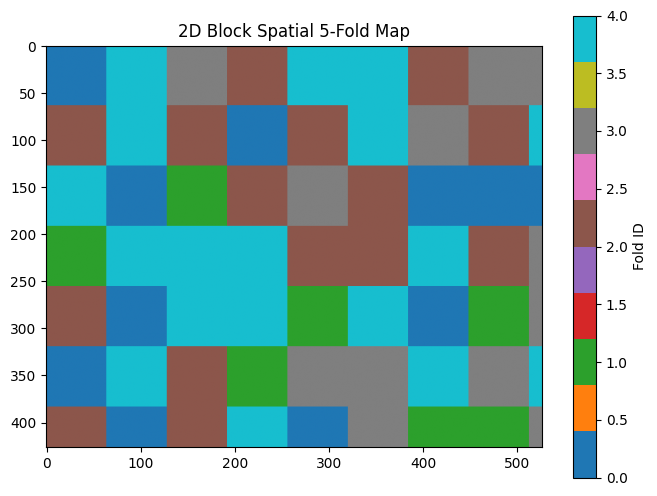

In [44]:
plt.figure(figsize=(8, 6))
plt.imshow(fold_map, cmap="tab10")
plt.colorbar(label="Fold ID")
plt.title("2D Block Spatial 5-Fold Map")
plt.show()

In [45]:
for k in range(5):
    train_dataset = SupervisedFloodDataset(
        X_full=X_full,
        y_full=y_full,
        patch_size=PATCH_SIZE,
        stride=STRIDE,
        fold_map=fold_map,
        val_fold=k,
        mode="train",
        drop_boundary=False
    )

    val_dataset = SupervisedFloodDataset(
        X_full=X_full,
        y_full=y_full,
        patch_size=PATCH_SIZE,
        stride=STRIDE,
        fold_map=fold_map,
        val_fold=k,
        mode="val",
        drop_boundary=False
    )

    print(k, len(train_dataset), len(val_dataset))

mode: train
total patches: 180
valid y patches: 137
boundary removed: 0
kept samples: 113
mode: val
total patches: 180
valid y patches: 137
boundary removed: 0
kept samples: 24
0 113 24
mode: train
total patches: 180
valid y patches: 137
boundary removed: 0
kept samples: 120
mode: val
total patches: 180
valid y patches: 137
boundary removed: 0
kept samples: 17
1 120 17
mode: train
total patches: 180
valid y patches: 137
boundary removed: 0
kept samples: 102
mode: val
total patches: 180
valid y patches: 137
boundary removed: 0
kept samples: 35
2 102 35
mode: train
total patches: 180
valid y patches: 137
boundary removed: 0
kept samples: 116
mode: val
total patches: 180
valid y patches: 137
boundary removed: 0
kept samples: 21
3 116 21
mode: train
total patches: 180
valid y patches: 137
boundary removed: 0
kept samples: 97
mode: val
total patches: 180
valid y patches: 137
boundary removed: 0
kept samples: 40
4 97 40


In [46]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [ ]:
# import pandas as pd

# fold_results = []

# for val_fold in range(5):
#     print("=" * 50)
#     print(f"Spatial Fold {val_fold + 1}/5")
#     print("=" * 50)

#     train_dataset = SupervisedFloodDataset(
#         X_full=X_full,
#         y_full=y_full,
#         patch_size=PATCH_SIZE,
#         stride=STRIDE,
#         fold_map=fold_map,
#         val_fold=val_fold,
#         mode="train",
#         drop_boundary=False
#     )

#     val_dataset = SupervisedFloodDataset(
#         X_full=X_full,
#         y_full=y_full,
#         patch_size=PATCH_SIZE,
#         stride=STRIDE,
#         fold_map=fold_map,
#         val_fold=val_fold,
#         mode="val",
#         drop_boundary=False
#     )

#     train_loader = DataLoader(
#         train_dataset,
#         batch_size=BATCH_SIZE,
#         shuffle=True
#     )

#     val_loader = DataLoader(
#         val_dataset,
#         batch_size=BATCH_SIZE,
#         shuffle=False
#     )

#     model = UNet(in_channels=X_full.shape[0]).to(device)

#     optimizer = torch.optim.Adam(
#         model.parameters(),
#         lr=LEARNING_RATE
#     )

#     best_val_rmse = np.inf
#     best_epoch = -1

#     for epoch in range(EPOCHS):
#         model.train()
#         train_losses = []

#         for X_batch, y_batch in train_loader:
#             X_batch = X_batch.to(device)
#             y_batch = y_batch.to(device)

#             optimizer.zero_grad()

#             pred = model(X_batch)

#             loss_main = masked_mse_loss(pred, y_batch)

#             if loss_main is None:
#                 continue

#             loss = loss_main + SMOOTHNESS_WEIGHT * smoothness_loss(pred)

#             loss.backward()
#             optimizer.step()

#             train_losses.append(loss.item())

#         train_loss = np.mean(train_losses) if len(train_losses) > 0 else np.nan

#         val_mae, val_rmse, val_r2 = validate_model(
#             model,
#             val_loader,
#             device
#         )

#         print(
#             f"Fold {val_fold+1}, "
#             f"Epoch {epoch+1}/{EPOCHS}, "
#             f"Train Loss: {train_loss:.6f}, "
#             f"Val MAE: {val_mae:.6f}, "
#             f"Val RMSE: {val_rmse:.6f}, "
#             f"Val R2: {val_r2:.6f}"
#         )

#         if np.isfinite(val_rmse) and val_rmse < best_val_rmse:
#             best_val_rmse = val_rmse
#             best_epoch = epoch + 1
#             best_val_mae = val_mae
#             best_val_r2 = val_r2

#     fold_results.append({
#         "fold": val_fold + 1,
#         "best_epoch": best_epoch,
#         "MAE": best_val_mae,
#         "RMSE": best_val_rmse,
#         "R2": best_val_r2
#     })

Spatial Fold 1/5
mode: train
total patches: 180
valid y patches: 137
boundary removed: 0
kept samples: 109
mode: val
total patches: 180
valid y patches: 137
boundary removed: 0
kept samples: 28
Fold 1, Epoch 1/50, Train Loss: 0.184293, Val MAE: 0.126233, Val RMSE: 0.358587, Val R2: 0.629449
Fold 1, Epoch 2/50, Train Loss: 0.114573, Val MAE: 0.092175, Val RMSE: 0.416157, Val R2: 0.500916
Fold 1, Epoch 3/50, Train Loss: 0.095990, Val MAE: 0.106054, Val RMSE: 0.440008, Val R2: 0.442069
Fold 1, Epoch 4/50, Train Loss: 0.064628, Val MAE: 0.077689, Val RMSE: 0.312832, Val R2: 0.717980
Fold 1, Epoch 5/50, Train Loss: 0.069076, Val MAE: 0.050389, Val RMSE: 0.270949, Val R2: 0.788441
Fold 1, Epoch 6/50, Train Loss: 0.057611, Val MAE: 0.054369, Val RMSE: 0.314181, Val R2: 0.715542
Fold 1, Epoch 7/50, Train Loss: 0.037241, Val MAE: 0.059942, Val RMSE: 0.314653, Val R2: 0.714686
Fold 1, Epoch 8/50, Train Loss: 0.031212, Val MAE: 0.054026, Val RMSE: 0.306772, Val R2: 0.728800
Fold 1, Epoch 9/50, Tr

In [47]:
import copy
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader

EARLY_STOPPING_PATIENCE = 10
MIN_DELTA = 1e-4

fold_results = []
fold_best_models = {}

for val_fold in range(5):
    print("=" * 50)
    print(f"Spatial Fold {val_fold + 1}/5")
    print("=" * 50)

    train_dataset = SupervisedFloodDataset(
        X_full=X_full,
        y_full=y_full,
        patch_size=PATCH_SIZE,
        stride=STRIDE,
        fold_map=fold_map,
        val_fold=val_fold,
        mode="train",
        drop_boundary=False
    )

    val_dataset = SupervisedFloodDataset(
        X_full=X_full,
        y_full=y_full,
        patch_size=PATCH_SIZE,
        stride=STRIDE,
        fold_map=fold_map,
        val_fold=val_fold,
        mode="val",
        drop_boundary=False
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    print(f"Train patches: {len(train_dataset)}")
    print(f"Validation patches: {len(val_dataset)}")

    model = UNet(
        in_channels=X_full.shape[0]
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE
    )

    # Best validation metrics for this fold
    best_val_rmse = np.inf
    best_val_mae = np.nan
    best_val_r2 = np.nan
    best_epoch = -1
    best_model_state = None

    # Early-stopping counter
    epochs_without_improvement = 0

    for epoch in range(EPOCHS):
        # =========================
        # Training
        # =========================
        model.train()
        train_losses = []

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            pred = model(X_batch)

            loss_main = masked_mse_loss(
                pred,
                y_batch
            )

            if loss_main is None:
                continue

            loss_smooth = smoothness_loss(pred)

            loss = (
                loss_main
                + SMOOTHNESS_WEIGHT * loss_smooth
            )

            if not torch.isfinite(loss):
                print("Non-finite training loss detected. Batch skipped.")
                continue

            loss.backward()
            optimizer.step()

            train_losses.append(loss.item())

        train_loss = (
            np.mean(train_losses)
            if len(train_losses) > 0
            else np.nan
        )

        # =========================
        # Validation
        # =========================
        val_mae, val_rmse, val_r2 = validate_model(
            model,
            val_loader,
            device
        )

        print(
            f"Fold {val_fold + 1}, "
            f"Epoch {epoch + 1}/{EPOCHS}, "
            f"Train Loss: {train_loss:.6f}, "
            f"Val MAE: {val_mae:.6f}, "
            f"Val RMSE: {val_rmse:.6f}, "
            f"Val R2: {val_r2:.6f}"
        )

        # =========================
        # Early stopping
        # =========================
        if not np.isfinite(val_rmse):
            epochs_without_improvement += 1

            print(
                "Validation RMSE is not finite. "
                f"Patience: {epochs_without_improvement}/"
                f"{EARLY_STOPPING_PATIENCE}"
            )

        elif val_rmse < best_val_rmse - MIN_DELTA:
            best_val_rmse = val_rmse
            best_val_mae = val_mae
            best_val_r2 = val_r2
            best_epoch = epoch + 1

            # Save a copy of the best model weights
            best_model_state = copy.deepcopy(
                model.state_dict()
            )

            # Reset patience
            epochs_without_improvement = 0

            print(
                f"New best model for fold {val_fold + 1}: "
                f"RMSE = {best_val_rmse:.6f}"
            )

        else:
            epochs_without_improvement += 1

            print(
                f"No improvement. Patience: "
                f"{epochs_without_improvement}/"
                f"{EARLY_STOPPING_PATIENCE}"
            )

        if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
            print(
                f"Early stopping fold {val_fold + 1} "
                f"at epoch {epoch + 1}."
            )
            break

    # Restore the best model for this fold
    if best_model_state is not None:
        model.load_state_dict(best_model_state)

        # Store on CPU to reduce GPU memory use
        fold_best_models[val_fold + 1] = {
            key: value.detach().cpu().clone()
            for key, value in best_model_state.items()
        }

        print(
            f"Fold {val_fold + 1} finished. "
            f"Best epoch: {best_epoch}, "
            f"Best RMSE: {best_val_rmse:.6f}"
        )

    else:
        print(
            f"Warning: Fold {val_fold + 1} did not produce "
            "a valid validation RMSE."
        )

    fold_results.append({
        "fold": val_fold + 1,
        "best_epoch": best_epoch,
        "MAE": best_val_mae,
        "RMSE": best_val_rmse
        if np.isfinite(best_val_rmse)
        else np.nan,
        "R2": best_val_r2,
        "epochs_run": epoch + 1
    })

    # Release GPU memory before the next fold
    del model
    del optimizer
    torch.cuda.empty_cache()

Spatial Fold 1/5
mode: train
total patches: 180
valid y patches: 137
boundary removed: 0
kept samples: 113
mode: val
total patches: 180
valid y patches: 137
boundary removed: 0
kept samples: 24
Train patches: 113
Validation patches: 24
Fold 1, Epoch 1/50, Train Loss: 0.170079, Val MAE: 0.102530, Val RMSE: 0.403257, Val R2: 0.633676
New best model for fold 1: RMSE = 0.403257
Fold 1, Epoch 2/50, Train Loss: 0.083936, Val MAE: 0.079680, Val RMSE: 0.352996, Val R2: 0.719302
New best model for fold 1: RMSE = 0.352996
Fold 1, Epoch 3/50, Train Loss: 0.072579, Val MAE: 0.116069, Val RMSE: 0.483140, Val R2: 0.474168
No improvement. Patience: 1/10
Fold 1, Epoch 4/50, Train Loss: 0.077964, Val MAE: 0.085833, Val RMSE: 0.386137, Val R2: 0.664121
No improvement. Patience: 2/10
Fold 1, Epoch 5/50, Train Loss: 0.056182, Val MAE: 0.069932, Val RMSE: 0.338821, Val R2: 0.741392
New best model for fold 1: RMSE = 0.338821
Fold 1, Epoch 6/50, Train Loss: 0.071568, Val MAE: 0.059549, Val RMSE: 0.290260, Va

In [48]:
results_df = pd.DataFrame(fold_results)

print(results_df)

print("MAE mean:", results_df["MAE"].mean())
print("MAE std:", results_df["MAE"].std())

print("RMSE mean:", results_df["RMSE"].mean())
print("RMSE std:", results_df["RMSE"].std())

print("R2 mean:", results_df["R2"].mean())
print("R2 std:", results_df["R2"].std())

   fold  best_epoch       MAE      RMSE        R2  epochs_run
0     1           6  0.059549  0.290260  0.810209          16
1     2          16  0.133839  0.395469  0.808325          26
2     3          38  0.013017  0.125838  0.910227          48
3     4          38  0.010496  0.075867  0.892799          48
4     5          30  0.018691  0.129036  0.904613          40
MAE mean: 0.047118276
MAE std: 0.05240998417139053
RMSE mean: 0.20329419
RMSE std: 0.1343929022550583
R2 mean: 0.8652344
R2 std: 0.05148132145404816


## U-net model for downscaling

In [50]:
class SupervisedFloodDataset(Dataset):
    def __init__(self, X_full, y_full, patch_size=160, stride=None):
        self.X = X_full.astype("float32")
        self.y = y_full[np.newaxis, :, :].astype("float32")
        self.patch_size = patch_size
        self.stride = stride or patch_size
        self.samples = []

        _, height, width = self.X.shape
        for i in range(0, height - patch_size + 1, self.stride):
            for j in range(0, width - patch_size + 1, self.stride):
                y_patch = self.y[:, i:i + patch_size, j:j + patch_size]
                if np.isfinite(y_patch).sum() == 0:
                    continue
                self.samples.append((i, j))

        print("train_dataset length:", len(self.samples))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        i, j = self.samples[idx]
        X_patch = self.X[:, i:i + self.patch_size, j:j + self.patch_size]
        y_patch = self.y[:, i:i + self.patch_size, j:j + self.patch_size]
        return (
            torch.tensor(X_patch, dtype=torch.float32),
            torch.tensor(y_patch, dtype=torch.float32),
        )

In [51]:
PATCH_SIZE,STRIDE

(64, 32)

In [52]:
train_dataset = SupervisedFloodDataset(
    X_full=X_full,
    y_full=y_full,
    patch_size=PATCH_SIZE,
    stride=STRIDE,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

if len(train_dataset) == 0:
    raise ValueError("No valid supervised training patches were found. Check y_full coverage and PATCH_SIZE.")

train_dataset length: 137


In [53]:
in_channels = 6

model = UNet(in_channels=in_channels).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

train_loss_history = []

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0.0
    valid_batches = 0

    for X_patch, y_patch in train_loader:
        X_patch = X_patch.to(device)
        y_patch = y_patch.to(device)

        pred = model(X_patch)

        loss1 = masked_mse_loss(pred, y_patch)
        if loss1 is None:
            continue

        loss2 = smoothness_loss(pred)
        loss = loss1 + SMOOTHNESS_WEIGHT * loss2

        if torch.isnan(loss):
            print("NaN loss detected")
            print("loss1:", loss1)
            print("loss2:", loss2)
            break

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        valid_batches += 1

    if valid_batches == 0:
        print(f"Epoch {epoch + 1}: no valid batches")
    else:
        epoch_loss = total_loss / valid_batches
        train_loss_history.append(epoch_loss)

        print(
            f"Epoch {epoch + 1}/{EPOCHS}, "
            f"Loss: {epoch_loss:.6f}"
        )

torch.save(model.state_dict(), "final_unet_all_data.pth")
print("Final model saved.")

Epoch 1/50, Loss: 0.160966
Epoch 2/50, Loss: 0.095947
Epoch 3/50, Loss: 0.077943
Epoch 4/50, Loss: 0.056551
Epoch 5/50, Loss: 0.051534
Epoch 6/50, Loss: 0.045626
Epoch 7/50, Loss: 0.030174
Epoch 8/50, Loss: 0.031572
Epoch 9/50, Loss: 0.040216
Epoch 10/50, Loss: 0.029208
Epoch 11/50, Loss: 0.015849
Epoch 12/50, Loss: 0.029754
Epoch 13/50, Loss: 0.023756
Epoch 14/50, Loss: 0.018545
Epoch 15/50, Loss: 0.025701
Epoch 16/50, Loss: 0.022743
Epoch 17/50, Loss: 0.013565
Epoch 18/50, Loss: 0.034267
Epoch 19/50, Loss: 0.011136
Epoch 20/50, Loss: 0.010305
Epoch 21/50, Loss: 0.015376
Epoch 22/50, Loss: 0.011890
Epoch 23/50, Loss: 0.010729
Epoch 24/50, Loss: 0.007302
Epoch 25/50, Loss: 0.007214
Epoch 26/50, Loss: 0.013361
Epoch 27/50, Loss: 0.007999
Epoch 28/50, Loss: 0.010299
Epoch 29/50, Loss: 0.007765
Epoch 30/50, Loss: 0.009442
Epoch 31/50, Loss: 0.004267
Epoch 32/50, Loss: 0.004551
Epoch 33/50, Loss: 0.007592
Epoch 34/50, Loss: 0.006483
Epoch 35/50, Loss: 0.006127
Epoch 36/50, Loss: 0.010344
E

In [ ]:
def predict_full_map_overlap(
    model,
    X_full,
    patch_size=PATCH_SIZE,
    stride=STRIDE,
    batch_size=4,
    device="cpu"
):
    model.eval()

    _, height, width = X_full.shape

    pad_h = max(patch_size - height, 0)
    pad_w = max(patch_size - width, 0)

    if height > patch_size:
        pad_h = (stride - (height - patch_size) % stride) % stride

    if width > patch_size:
        pad_w = (stride - (width - patch_size) % stride) % stride

    X_pad = np.pad(
        X_full,
        ((0, 0), (0, pad_h), (0, pad_w)),
        mode="constant",
        constant_values=0,
    )

    _, padded_height, padded_width = X_pad.shape

    pred_sum = np.zeros(
        (padded_height, padded_width),
        dtype="float32"
    )

    pred_count = np.zeros(
        (padded_height, padded_width),
        dtype="float32"
    )

    patches = []
    positions = []

    with torch.no_grad():

        for i in range(0, padded_height - patch_size + 1, stride):
            for j in range(0, padded_width - patch_size + 1, stride):

                patches.append(
                    X_pad[:, i:i + patch_size, j:j + patch_size]
                )
                positions.append((i, j))

                if len(patches) == batch_size:
                    batch = torch.tensor(
                        np.stack(patches),
                        dtype=torch.float32
                    ).to(device)

                    batch_pred = model(batch).cpu().numpy()[:, 0]

                    for pred_patch, (pi, pj) in zip(batch_pred, positions):
                        pred_sum[
                            pi:pi + patch_size,
                            pj:pj + patch_size
                        ] += pred_patch

                        pred_count[
                            pi:pi + patch_size,
                            pj:pj + patch_size
                        ] += 1

                    patches = []
                    positions = []

        if patches:
            batch = torch.tensor(
                np.stack(patches),
                dtype=torch.float32
            ).to(device)

            batch_pred = model(batch).cpu().numpy()[:, 0]

            for pred_patch, (pi, pj) in zip(batch_pred, positions):
                pred_sum[
                    pi:pi + patch_size,
                    pj:pj + patch_size
                ] += pred_patch

                pred_count[
                    pi:pi + patch_size,
                    pj:pj + patch_size
                ] += 1

    pred_pad = pred_sum / np.maximum(pred_count, 1)

    return pred_pad[:height, :width]

In [ ]:
pred_full = predict_full_map_overlap(
    model=model,
    X_full=X_full,
    patch_size=PATCH_SIZE,
    stride=STRIDE,
    batch_size=BATCH_SIZE,
    device=device,
)

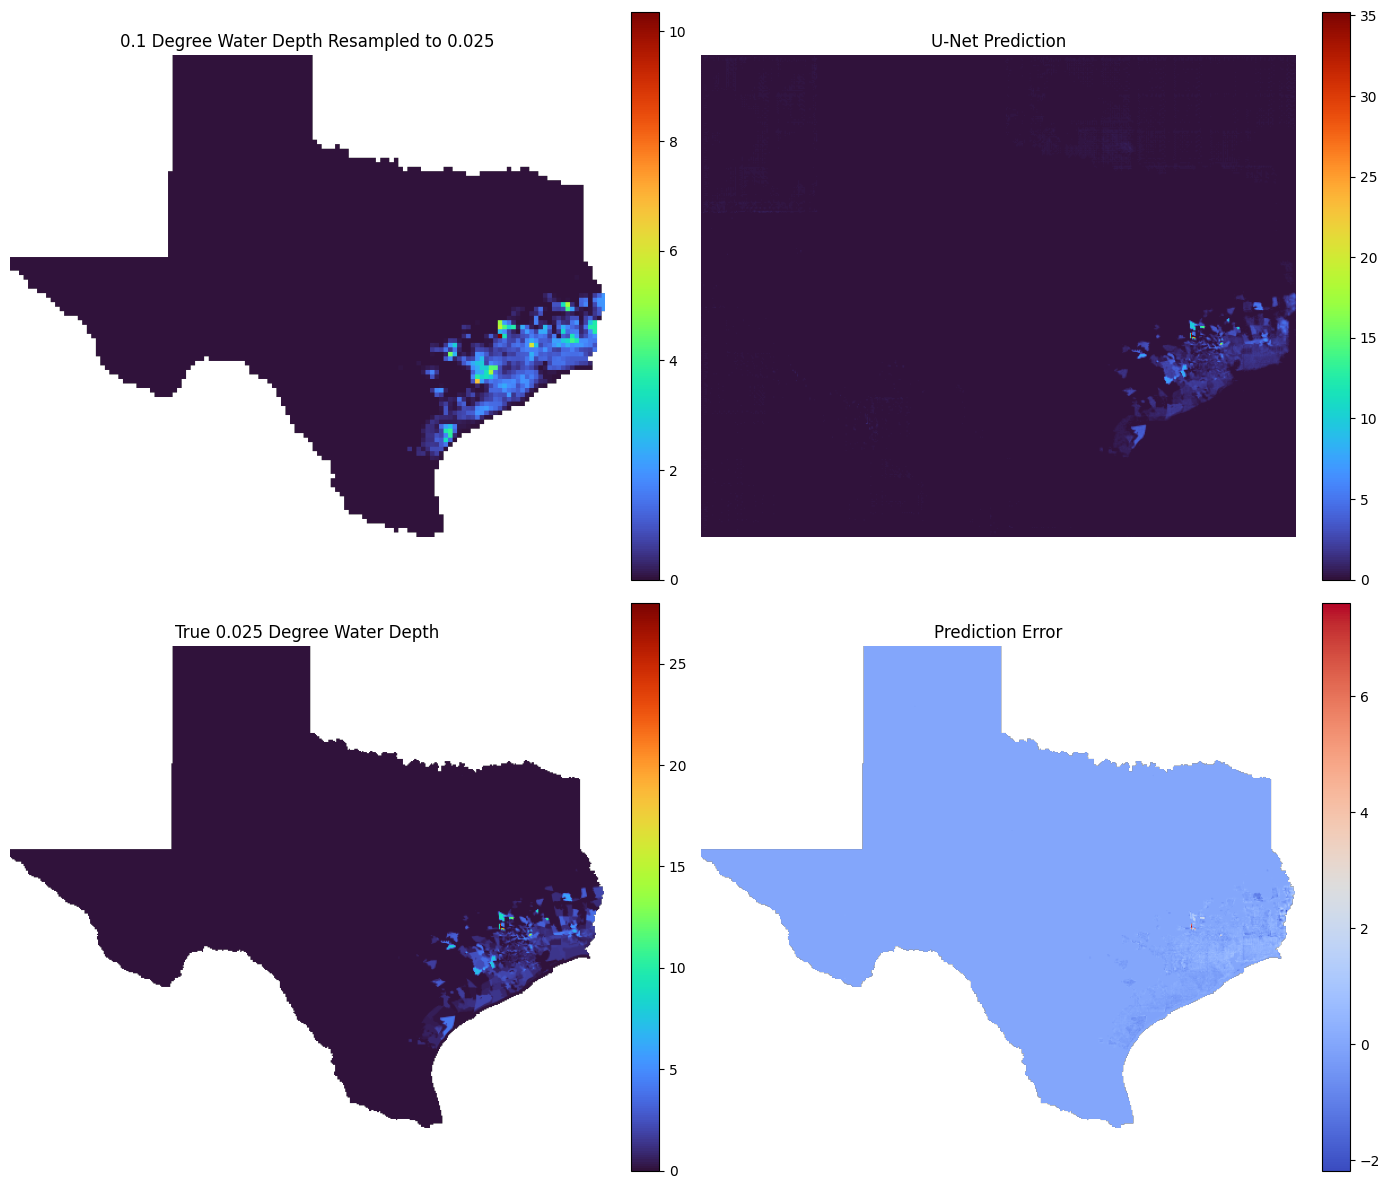

In [ ]:
error_map = pred_full - y_full

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
plots = [
    (water_01_up, "0.1 Degree Water Depth Resampled to 0.025", "turbo"),
    (pred_full, "U-Net Prediction", "turbo"),
    (water_025, "True 0.025 Degree Water Depth", "turbo"),
    (error_map, "Prediction Error", "coolwarm"),
]

for ax, (arr, title, cmap) in zip(axes.ravel(), plots):
    im = ax.imshow(arr, cmap=cmap)
    ax.set_title(title)
    ax.axis("off")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [ ]:
import geopandas as gpd
import rasterio
from rasterio.features import geometry_mask
import numpy as np

texas_mask = geometry_mask(
    [texas_boundary],
    out_shape=pred_full.shape,
    transform=water_025_transform,
    invert=True
)

pred_full_tx = np.where(
    texas_mask,
    pred_full,
    np.nan
)

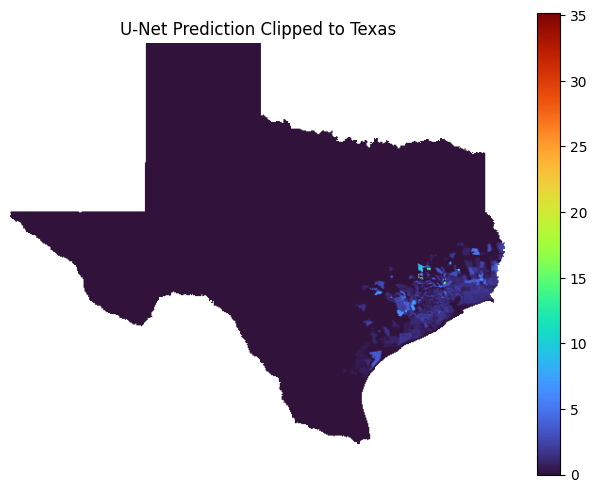

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.imshow(pred_full_tx, cmap="turbo")
plt.colorbar()
plt.title("U-Net Prediction Clipped to Texas")
plt.axis("off")
plt.show()

In [ ]:
profile = water_025_profile.copy()

profile.update(
    dtype="float32",
    count=1,
    nodata=-9999,
    compress="lzw"
)

pred_save = np.where(
    np.isfinite(pred_full_tx),
    pred_full_tx,
    -9999
).astype("float32")

with rasterio.open("pred_full_texas.tif", "w", **profile) as dst:
    dst.write(pred_save, 1)

print("Saved: pred_full_texas.tif")

Saved: pred_full_texas.tif
